### Workshop 5

### Name: Nayanika Dubey
### Student ID: 2408008


**Syntax of Conv2D Layer**

In [95]:
from tensorflow.keras.layers import Conv2D

# Define example values for filters and kernel_size
filters = 32
kernel_size = (3, 3)

layer = Conv2D(filters, kernel_size, strides=(1,1), padding="valid", activation=None, use_bias=True, kernel_initializer="glorot_uniform")
print(layer)

<Conv2D name=conv2d_17, built=False>


**End - to - End CNN Model**

In [96]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
# Load a sample dataset (MNIST for simplicity)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
# Normalize and reshape data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, axis=-1) # Add channel dimension
x_test = np.expand_dims(x_test, axis=-1)
# Define a simple CNN model
model = keras.Sequential([
layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
layers.MaxPooling2D((2, 2)),
layers.Conv2D(64, (3, 3), activation="relu"),
layers.MaxPooling2D((2, 2)),
layers.Flatten(),
layers.Dense(128, activation="relu"),
layers.Dense(10, activation="softmax") # 10 classes for MNIST digits
])
# Compile the model
model.compile(optimizer="adam",

loss="sparse_categorical_crossentropy",
metrics=["accuracy"])

# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))
# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")
# Make predictions
predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)
print("Predicted labels:", predicted_labels)
print("Actual labels: ", y_test[:5])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 19ms/step - accuracy: 0.9574 - loss: 0.1400 - val_accuracy: 0.9784 - val_loss: 0.0641
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - accuracy: 0.9856 - loss: 0.0467 - val_accuracy: 0.9886 - val_loss: 0.0366
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9901 - loss: 0.0316 - val_accuracy: 0.9896 - val_loss: 0.0294
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9927 - loss: 0.0226 - val_accuracy: 0.9872 - val_loss: 0.0400
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9946 - loss: 0.0176 - val_accuracy: 0.9918 - val_loss: 0.0280
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9918 - loss: 0.0280
Test accuracy: 0.9918
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Predicted labels: [7 2 1 0 4]
Actual labels:  [7 2 1 0 4]


#Task 1: Data Understanding and Visualisation

### 1a – Visualise one random image per class

In [97]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [98]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Colab Notebooks/AI ML/Dataset/FruitinAmazon.zip"
extract_path = "/content/drive/MyDrive/Colab Notebooks/AI ML/Dataset/FruitinAmazon"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Unzipped successfully! Path:  {extract_path}")

Unzipped successfully! Path:  /content/drive/MyDrive/Colab Notebooks/AI ML/Dataset/FruitinAmazon


Classes found (6): ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


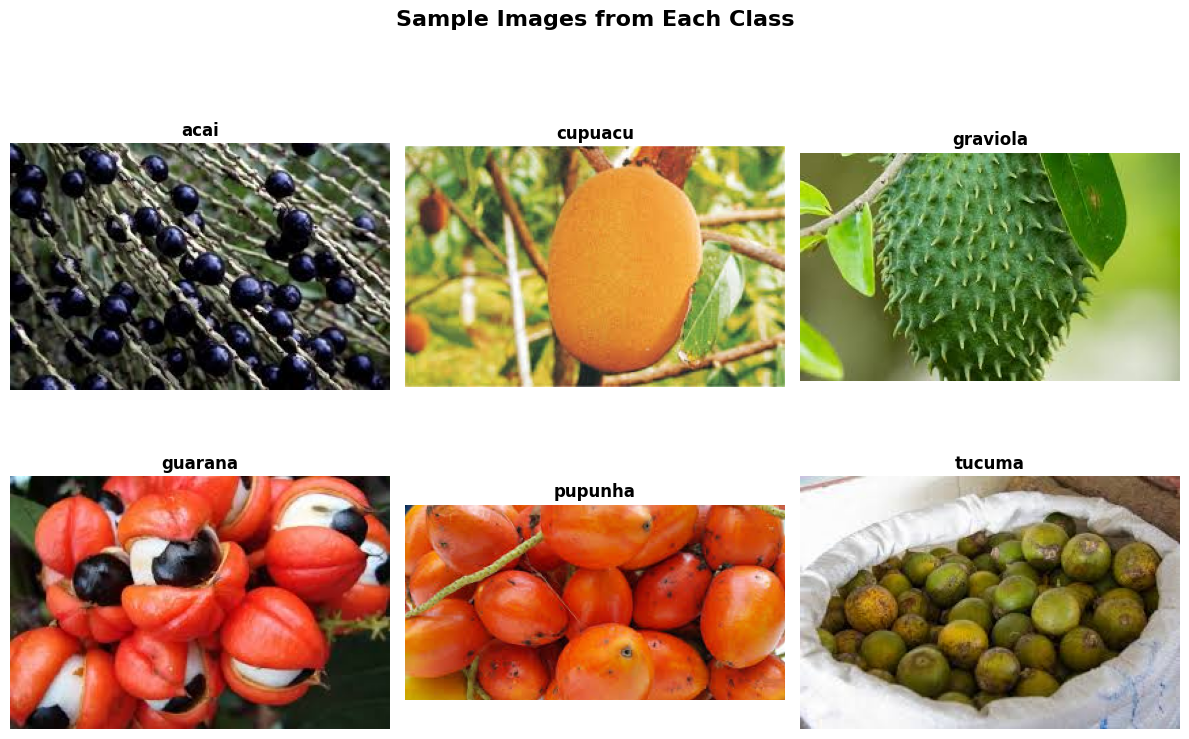


Observation: The dataset contains 6 Amazon fruit classes with varying
colours, textures, sizes and backgrounds - typical real-world challenges.


In [99]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Assuming TRAIN_DIR needs to be defined for a dataset.
# This is a placeholder; you'll need to set the correct path to your training data.
# For example, if your data is in a folder named 'train' in the current directory:
TRAIN_DIR = '/content/drive/MyDrive/Colab Notebooks/AI ML/Dataset/FruitinAmazon/FruitinAmazon/train'

# Get all class directories from the train folder
class_dirs = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])
num_classes = len(class_dirs)
print(f"Classes found ({num_classes}):", class_dirs)

# Select one random image from each class
sample_images = []
sample_labels = []
for cls in class_dirs:
    cls_path  = os.path.join(TRAIN_DIR, cls)
    img_files = [f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    chosen    = random.choice(img_files)
    sample_images.append(os.path.join(cls_path, chosen))
    sample_labels.append(cls)

# Display in a grid with 2 rows
cols = (num_classes + 1) // 2          # number of columns
rows = 2
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

for idx, (img_path, label) in enumerate(zip(sample_images, sample_labels)):
    img = Image.open(img_path).convert('RGB')
    axes[idx].imshow(img)
    axes[idx].set_title(label, fontsize=12, fontweight='bold')
    axes[idx].axis('off')

# Hide any unused axes
for j in range(len(sample_images), len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('task1_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nObservation: The dataset contains 6 Amazon fruit classes with varying")
print("colours, textures, sizes and backgrounds - typical real-world challenges.")


### 1b – Check for corrupted images

In [100]:
corrupted = []

for cls in class_dirs:
    cls_path = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_path):
        img_path = os.path.join(cls_path, fname)
        if not os.path.isfile(img_path):
            continue
        try:
            with Image.open(img_path) as img:
                img.verify()          # verify integrity without decoding
        except (IOError, SyntaxError):
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if not corrupted:
    print("No Corrupted Images Found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted)}")

No Corrupted Images Found.


# Task 2: Loading and Preprocessing Image Data

In [101]:
import tensorflow as tf

# Define image preprocessing parameters
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
# Assuming a similar directory structure for test data, adjust if needed
TEST_DIR = '/content/drive/MyDrive/Colab Notebooks/AI ML/Dataset/FruitinAmazon/FruitinAmazon/test'

# Rescaling layer – normalise pixel values from [0, 255] → [0, 1]
rescale = tf.keras.layers.Rescaling(1.0 / 255)

# ── Training dataset ──────────────────────────────────────────────
train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=123
)
# Capture class names from the training dataset before mapping
CLASS_NAMES = train_ds_raw.class_names
num_classes = len(CLASS_NAMES)
print("Class names:", CLASS_NAMES)

train_ds = train_ds_raw.map(lambda x, y: (rescale(x), y))

#  Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=123
)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

#Test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Performance optimisation
AUTOTUNE  = tf.data.AUTOTUNE
train_ds  = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds    = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds   = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


# Task 3: Implement the CNN Architecture

In [102]:
def build_cnn(input_shape, num_classes):
    """
    CNN architecture as specified in the worksheet:
    Conv(32, 3×3, same) → ReLU → MaxPool(2×2)
    Conv(32, 3×3, same) → ReLU → MaxPool(2×2)
    Flatten → Dense(128) → Dense(64) → Dense(num_classes, softmax)
    """
    model = keras.Sequential([
        # Convolutional Block 1
        layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            padding='same',
            strides=(1, 1),
            activation='relu',
            input_shape=input_shape,
            name='conv1'
        ),
        layers.MaxPooling2D(
            pool_size=(2, 2),
            strides=2,
            name='pool1'
        ),

        # Convolutional Block 2
        layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            padding='same',
            strides=(1, 1),
            activation='relu',
            name='conv2'
        ),
        layers.MaxPooling2D(
            pool_size=(2, 2),
            strides=2,
            name='pool2'
        ),

        # Fully Connected Network
        layers.Flatten(name='flatten'),

        # Hidden Layer 1 (128 neurons)
        layers.Dense(128, activation='relu', name='dense_128'),

        # Hidden Layer 2 (64 neurons)
        layers.Dense(64, activation='relu', name='dense_64'),

        # Output Layer
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name='Fruit_CNN')

    return model


INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)
model = build_cnn(INPUT_SHAPE, num_classes)
model.summary()

Model: "Fruit_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

# Task 4: Compile the Model

In [103]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled successfully.")

Model compiled successfully.


In [104]:
# 1. Save the best model (highest val_accuracy)
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath='best_fruit_cnn.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# 2. Stop training early if val_loss stops improving
early_stop_cb = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,            # wait 20 epochs before stopping
    restore_best_weights=True,
    verbose=1
)

# 3. Reduce learning rate on plateau
lr_reduce_cb = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

# Define EPOCHS
EPOCHS = 50 # You can adjust this value

# Training
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,      # already set inside the dataset
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb, lr_reduce_cb],
    verbose=1
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.1250 - loss: 1.8454
Epoch 1: val_accuracy improved from None to 0.33333, saving model to best_fruit_cnn.h5



Epoch 1: finished saving model to best_fruit_cnn.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 455ms/step - accuracy: 0.1250 - loss: 1.8729 - val_accuracy: 0.3333 - val_loss: 1.4993 - learning_rate: 0.0010
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.4994 - loss: 1.5705
Epoch 2: val_accuracy improved from 0.33333 to 0.50000, saving model to best_fruit_cnn.h5



Epoch 2: finished saving model to best_fruit_cnn.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 322ms/step - accuracy: 0.5139 - loss: 1.5223 - val_accuracy: 0.5000 - val_loss: 1.2137 - learning_rate: 0.0010
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.4196 - loss: 1.3217
Epoch 3: val_accuracy improved from 0.50000 to 0.88889, saving model to best_fruit_cnn.h5



Epoch 3: finished saving model to best_fruit_cnn.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 439ms/step - accuracy: 0.4306 - loss: 1.2914 - val_accuracy: 0.8889 - val_loss: 0.7731 - learning_rate: 0.0010
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.7141 - loss: 0.9373
Epoch 4: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 311ms/step - accuracy: 0.7361 - loss: 0.8872 - val_accuracy: 0.6111 - val_loss: 0.9474 - learning_rate: 0.0010
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.7697 - loss: 0.7213
Epoch 5: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 299ms/step - accuracy: 0.7778 - loss: 0.6719 - val_accuracy: 0.8889 - val_loss: 0.4639 - learning_rate: 0.0010
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.8895 - loss: 0.4417
Epoch 6: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 298ms/step - accuracy: 0.9028 - loss: 0.3847 - val_accuracy: 0.7778 - val_loss: 1.0238 - learning

# Visualise Training

In [105]:
# Accuracy Plot
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss Plot
axes[1].plot(history.history['loss'],     label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training and Validation Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('task4_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

# Task 5: Evaluate the Model

In [106]:
print("Evaluating on TEST set")

test_loss, test_acc = model.evaluate(test_ds, verbose=1)

print(f"\nTest Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}  ({test_acc * 100:.2f}%)")

Evaluating on TEST set
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.5333 - loss: 1.1175

Test Loss    : 1.1175
Test Accuracy: 0.5333  (53.33%)


# Task 6: Save and Load the Model

In [107]:
#  Save
MODEL_PATH = '/content/drive/MyDrive/Colab Notebooks/AI ML/Dataset/FruitinAmazon/fruit_cnn_final.h5'
model.save(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")

# Load
loaded_model = keras.models.load_model(MODEL_PATH)
print("Model loaded successfully.")

# Re-evaluate
print("\nRe-evaluating loaded model on TEST set:")
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=1)
print(f"Loaded Model – Test Loss: {loaded_loss:.4f} | Test Accuracy: {loaded_acc:.4f}")

Model saved to: /content/drive/MyDrive/Colab Notebooks/AI ML/Dataset/FruitinAmazon/fruit_cnn_final.h5
Model loaded successfully.

Re-evaluating loaded model on TEST set:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.5333 - loss: 1.1175
Loaded Model – Test Loss: 1.1175 | Test Accuracy: 0.5333


# Task 7: Predictions and Classification Report

In [108]:
from sklearn.metrics import classification_report

# Collect all true labels and predictions from the test set
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_pred_probs.extend(preds)
    y_true.extend(labels.numpy())

y_true  = np.array(y_true)
y_pred  = np.argmax(np.array(y_pred_probs), axis=1)

# Sample predictions
print("Sample Predictions (first 10 test images):")
print(f"{'Index':<8}{'Predicted':<20}{'Actual':<20}")
for i in range(min(10, len(y_true))):
    print(f"{i:<8}{CLASS_NAMES[y_pred[i]]:<20}{CLASS_NAMES[y_true[i]]:<20}")

print()

# Classification Report

print("CLASSIFICATION REPORT")
report = classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES
)
print(report)

Sample Predictions (first 10 test images):
Index   Predicted           Actual              
0       acai                acai                
1       cupuacu             acai                
2       acai                acai                
3       acai                acai                
4       acai                acai                
5       cupuacu             cupuacu             
6       graviola            cupuacu             
7       graviola            cupuacu             
8       graviola            cupuacu             
9       cupuacu             cupuacu             

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        acai       0.80      0.80      0.80         5
     cupuacu       0.67      0.40      0.50         5
    graviola       0.50      1.00      0.67         5
     guarana       0.75      0.60      0.67         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.25      0.40      0.31         5

    accuracy   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Visualise Predictions on Sample Test Images

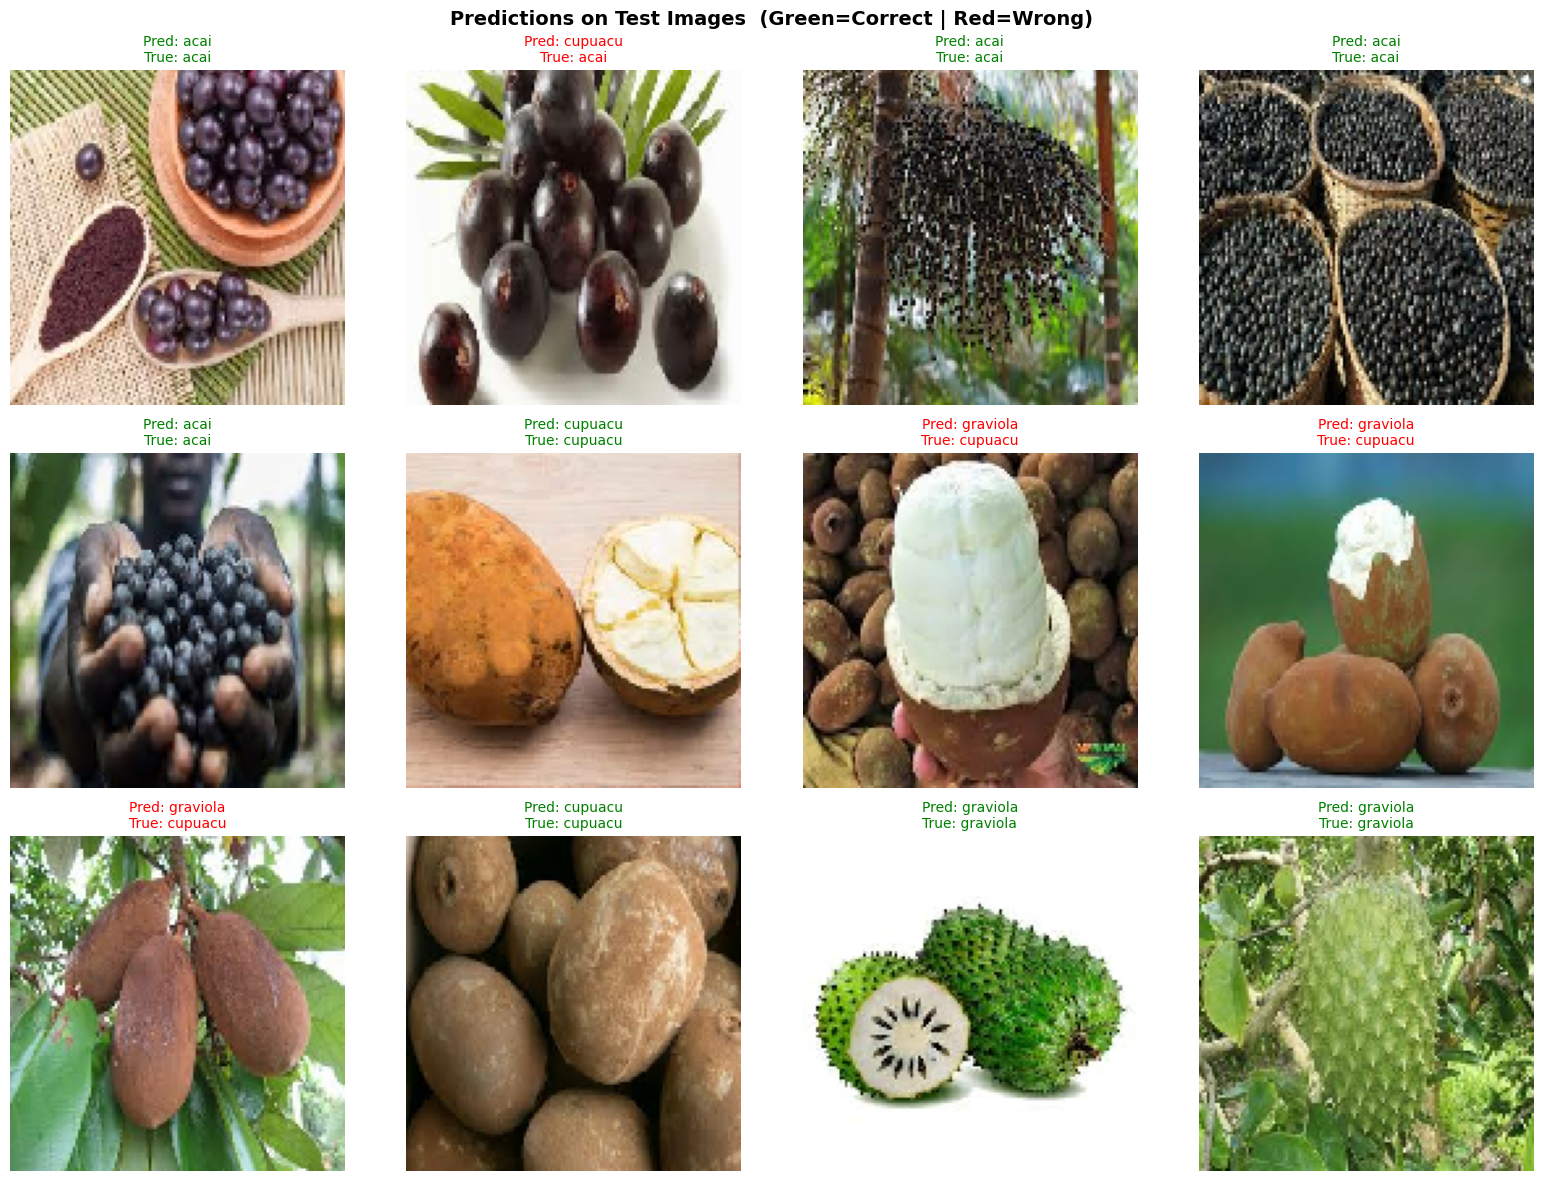

In [109]:
# Show first 12 test images with predicted vs actual labels
sample_imgs, sample_labels_batch = next(iter(test_ds))
sample_preds = np.argmax(loaded_model.predict(sample_imgs, verbose=0), axis=1)

n_show = min(12, len(sample_imgs))
cols   = 4
rows   = (n_show + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

for i in range(n_show):
    img       = sample_imgs[i].numpy()
    true_cls  = CLASS_NAMES[sample_labels_batch[i]]
    pred_cls  = CLASS_NAMES[sample_preds[i]]
    correct   = true_cls == pred_cls

    axes[i].imshow(img)
    axes[i].set_title(
        f"Pred: {pred_cls}\nTrue: {true_cls}",
        color='green' if correct else 'red',
        fontsize=10
    )
    axes[i].axis('off')

for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.suptitle('Predictions on Test Images  (Green=Correct | Red=Wrong)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task7_predictions.png', dpi=150, bbox_inches='tight')
plt.show()